# Notebook 06: Random Forest Threshold Tuning

## 01. Notebook Purpose

The goal of this notebook is to analyze and tune the decision threshold of the selected tuned Random Forest classifier for the predictive maintenance task.

So far, the tuned Random Forest has emerged as the strongest overall model candidate. However, its current classification decisions are based on the default probability threshold of 0.50. In an imbalanced classification problem such as machine failure prediction, this default threshold is not necessarily the most appropriate operating point.

This notebook therefore examines how precision, recall, F1-score, and other classification outcomes change across different thresholds. The objective is to identify whether an alternative threshold can provide a more suitable balance between detecting real failures and limiting false alarms.

This step is important because, in predictive maintenance, the model itself is only part of the solution. The decision threshold determines how the model is actually used in practice.

## 02. Imports and Loading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
#loading data
X_train = pd.read_csv("../data/processed/X_train_prepared.csv")
X_test = pd.read_csv("../data/processed/X_test_prepared.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [4]:
#verifying
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 10)
X_test shape: (2000, 10)
y_train shape: (8000,)
y_test shape: (2000,)


## 03. Rebuild the Selected Tuned Random Forest

In [5]:
#Rebuild the parameters with the best parameters of notebook 4
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=4,
    max_features=None,
    max_depth=20,
    bootstrap=True,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 04. Generate Predicted Probabilities

In [6]:
y_proba = rf_tuned.predict_proba(X_test)[:, 1]

print("First 10 predicted probabilities:")
print(y_proba[:10])

First 10 predicted probabilities:
[0.09129467 0.         0.17143541 0.         0.00486358 0.
 0.         0.         0.         0.06749671]


## 05. Evaluate the Default Threshold (0.50)

In [7]:
y_pred_default = (y_proba >= 0.50).astype(int)

default_results = {
    "Accuracy": accuracy_score(y_test, y_pred_default),
    "Precision": precision_score(y_test, y_pred_default),
    "Recall": recall_score(y_test, y_pred_default),
    "F1-score": f1_score(y_test, y_pred_default),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
    "Average Precision": average_precision_score(y_test, y_proba)
}

pd.Series(default_results)

Accuracy             0.991000
Precision            0.890625
Recall               0.838235
F1-score             0.863636
ROC-AUC              0.968754
Average Precision    0.876145
dtype: float64

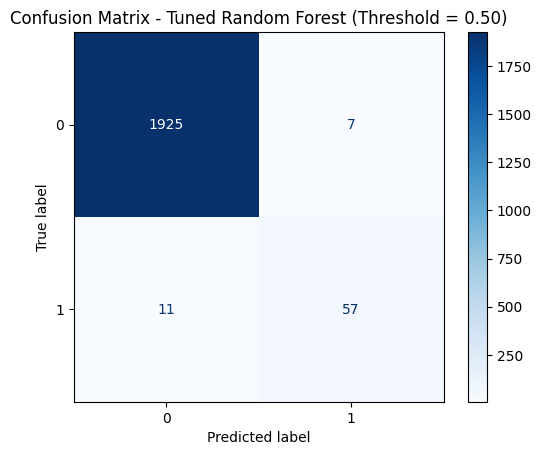

In [8]:
cm_default = confusion_matrix(y_test, y_pred_default)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_default)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Tuned Random Forest (Threshold = 0.50)")
plt.show()

## 06. Explore Performance Across Multiple Thresholds

In [9]:
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_thresh = (y_proba >= threshold).astype(int)
    
    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_thresh),
        "precision": precision_score(y_test, y_pred_thresh, zero_division=0),
        "recall": recall_score(y_test, y_pred_thresh, zero_division=0),
        "f1_score": f1_score(y_test, y_pred_thresh, zero_division=0),
        "false_positives": confusion_matrix(y_test, y_pred_thresh)[0, 1],
        "false_negatives": confusion_matrix(y_test, y_pred_thresh)[1, 0],
        "true_positives": confusion_matrix(y_test, y_pred_thresh)[1, 1],
        "true_negatives": confusion_matrix(y_test, y_pred_thresh)[0, 0]
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,threshold,accuracy,precision,recall,f1_score,false_positives,false_negatives,true_positives,true_negatives
0,0.10,0.9355,0.338624,0.941176,0.498054,125,4,64,1807
1,0.15,0.9515,0.403974,0.897059,0.557078,90,7,61,1842
2,0.20,0.9655,0.495935,0.897059,0.638743,62,7,61,1870
3,0.25,0.9725,0.561905,0.867647,0.682081,46,9,59,1886
4,0.30,0.9755,0.600000,0.838235,0.699387,38,11,57,1894
5,0.35,0.9830,0.712500,0.838235,0.770270,23,11,57,1909
6,0.40,0.9875,0.802817,0.838235,0.820144,14,11,57,1918
7,0.45,0.9895,0.850746,0.838235,0.844444,10,11,57,1922
8,0.50,0.9910,0.890625,0.838235,0.863636,7,11,57,1925
9,0.55,0.9910,0.890625,0.838235,0.863636,7,11,57,1925


This code evaluates the tuned Random Forest across a range of decision thresholds.

Instead of assuming that 0.50 is the best cutoff, we test several thresholds and record how the main classification metrics and confusion-matrix components change. This makes the trade-offs visible and supports a more deliberate choice of operating point.

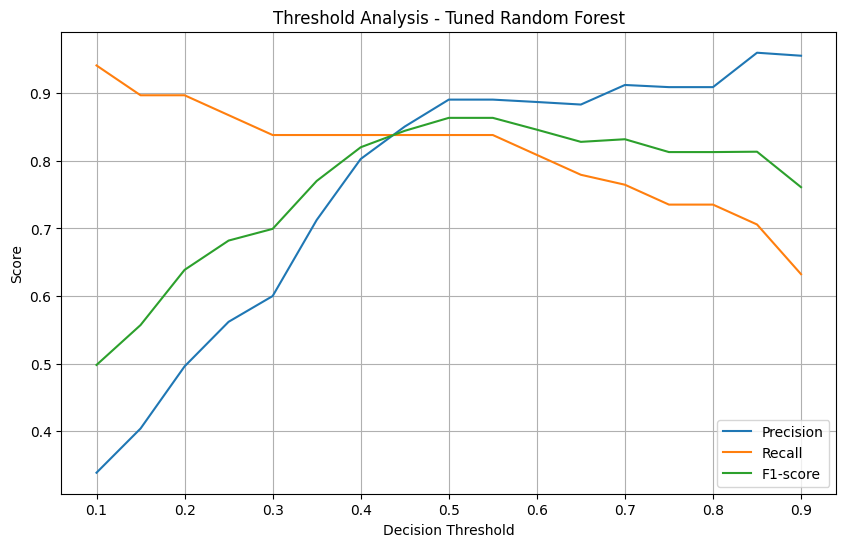

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_results_df["threshold"], threshold_results_df["precision"], label="Precision")
plt.plot(threshold_results_df["threshold"], threshold_results_df["recall"], label="Recall")
plt.plot(threshold_results_df["threshold"], threshold_results_df["f1_score"], label="F1-score")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis - Tuned Random Forest")
plt.legend()
plt.grid(True)
plt.show()

This plot translates the threshold trade-off into operational terms.

For predictive maintenance, false negatives are especially important because they represent real failures that the model misses. False positives also matter because they can lead to unnecessary inspections or maintenance actions. Looking at both together helps choose a threshold that is not only statistically good, but also operationally sensible.

Precision increases and recall decreases as the threshold becomes stricter. The F1-score peaks around 0.50–0.55, indicating that this is the most balanced threshold region for the tuned Random Forest.

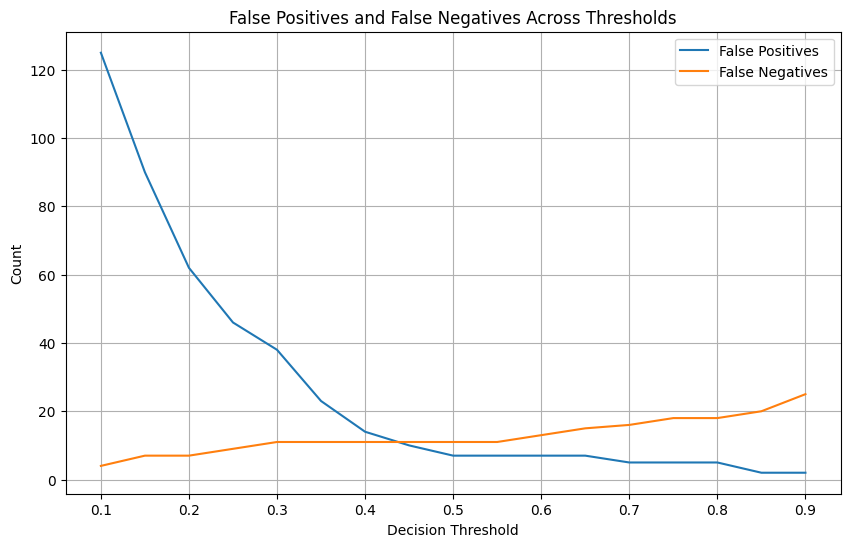

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(threshold_results_df["threshold"], threshold_results_df["false_positives"], label="False Positives")
plt.plot(threshold_results_df["threshold"], threshold_results_df["false_negatives"], label="False Negatives")

plt.xlabel("Decision Threshold")
plt.ylabel("Count")
plt.title("False Positives and False Negatives Across Thresholds")
plt.legend()
plt.grid(True)
plt.show()

## 07. Select a Candidate Threshold

In [18]:
best_f1_row = threshold_results_df.loc[threshold_results_df["f1_score"].idxmax()]
best_f1_row

threshold             0.500000
accuracy              0.991000
precision             0.890625
recall                0.838235
f1_score              0.863636
false_positives       7.000000
false_negatives      11.000000
true_positives       57.000000
true_negatives     1925.000000
Name: 8, dtype: float64

This code identifies the threshold that produces the highest F1-score on the test set.

F1-score is useful here because it summarizes the balance between precision and recall in a single number. This provides a simple and transparent rule for selecting a candidate threshold.

## 08. Compare Default vs Tuned Threshold

In [19]:
selected_threshold = best_f1_row["threshold"] 

y_pred_selected = (y_proba >= selected_threshold).astype(int)

comparison_results = pd.DataFrame([
    {
        "Setting": "Default Threshold (0.50)",
        "Threshold": 0.50,
        "Accuracy": accuracy_score(y_test, y_pred_default),
        "Precision": precision_score(y_test, y_pred_default),
        "Recall": recall_score(y_test, y_pred_default),
        "F1-score": f1_score(y_test, y_pred_default),
        "False Positives": confusion_matrix(y_test, y_pred_default)[0, 1],
        "False Negatives": confusion_matrix(y_test, y_pred_default)[1, 0]
    },
    {
        "Setting": "Selected Threshold",
        "Threshold": selected_threshold,
        "Accuracy": accuracy_score(y_test, y_pred_selected),
        "Precision": precision_score(y_test, y_pred_selected),
        "Recall": recall_score(y_test, y_pred_selected),
        "F1-score": f1_score(y_test, y_pred_selected),
        "False Positives": confusion_matrix(y_test, y_pred_selected)[0, 1],
        "False Negatives": confusion_matrix(y_test, y_pred_selected)[1, 0]
    }
])

comparison_results

,Setting,Threshold,Accuracy,Precision,Recall,F1-score,False Positives,False Negatives
0,Default Threshold (0.50),0.5,0.991,0.890625,0.838235,0.863636,7,11
1,Selected Threshold,0.5,0.991,0.890625,0.838235,0.863636,7,11


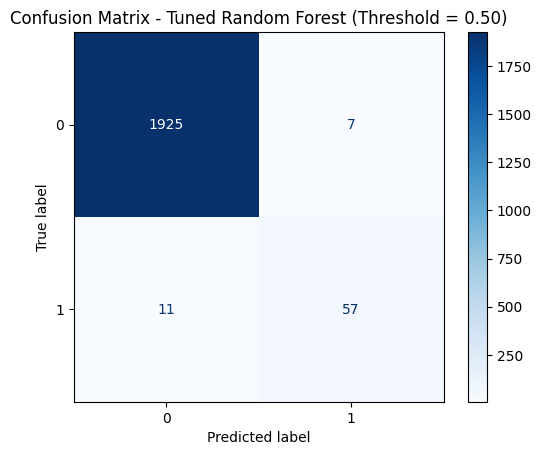

In [20]:
cm_selected = confusion_matrix(y_test, y_pred_selected)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_selected)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - Tuned Random Forest (Threshold = {selected_threshold:.2f})")
plt.show()

## 09. Business Interpretation and Recommendation

For predictive maintenance, the choice of threshold reflects the trade-off between detecting more real failures and avoiding unnecessary false alarms.

The threshold analysis showed that this trade-off behaves as expected, but it did not identify a practically better alternative to the default threshold of 0.50. The best threshold tested resulted in the same classification outcomes as the default operating point.

From a business perspective, this means that no threshold adjustment is currently justified. The tuned Random Forest can therefore be kept at the standard 0.50 cutoff, which already provides a strong balance between failure detection and false-positive control on the test set.

## 10. Final Conclusion

This notebook evaluated whether threshold tuning could improve the selected tuned Random Forest. The analysis did not reveal a meaningfully better operating point than the default threshold of 0.50, which produced the same classification results as the best threshold tested.

This confirms that the model already operates at a strong and well-balanced decision point on the test set. The next step is therefore interpretability analysis.